In [ ]:
import os
import sys

# Path to project root (works both in .py and .ipynb)
def get_project_root(levels_up=2):
    try:
        here = os.path.dirname(__file__)
    except NameError:
        here = os.getcwd()
    return os.path.abspath(os.path.join(here, *([".."] * levels_up)))

root_dir = get_project_root(2)

# Add paper folder
paper_dir = os.path.join(root_dir, "paper")
sys.path.insert(0, paper_dir)

# Import PyGhostID package and 
import PyGhostID as gid

import utils_paper as fun
print(fun.__file__)
import models_paper as mod

# other imports
import numpy as np
from scipy.integrate import solve_ivp
import jax
import jax.numpy as jnp
from jax.nn import sigmoid
from jax import jacfwd

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.pylab as pylab
from matplotlib.collections import LineCollection

# No warnings
import warnings
warnings.filterwarnings("ignore")

pylab.rcParams.update(fun.get_rcparams())
plt.rcParams.update({'font.family':'Arial'})

inCm = 1/2.54 # convert inch to cm for plotting

saveFigs = False

w:\GitHub\GhostID\paper\utils_paper.py


<>:15: SyntaxWarning: invalid escape sequence '\d'
<>:15: SyntaxWarning: invalid escape sequence '\d'
C:\Users\dkoch\AppData\Local\Temp\ipykernel_23292\595223546.py:15: SyntaxWarning: invalid escape sequence '\d'
  plt.xlabel('$x$'); plt.ylabel('$\dot{x}$')


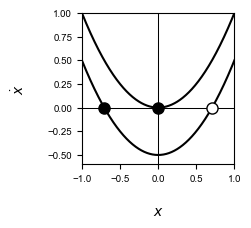

In [ ]:
x_range = np.linspace(-1,1,500)
mu = -0.5
plt.figure(figsize=(5*inCm,5*inCm))

plt.plot(x_range,x_range**2+mu,'-k')
plt.plot(x_range,x_range**2,'-k')
plt.plot(x_range,x_range*0,'-k',lw=0.75)
plt.plot([0,0],[-0.6,1],'-k',lw=0.75)
plt.plot(0,0,'ok',ms=8,mec='k')
plt.plot(-np.sqrt(-mu),0,'ok',ms=8,mec='k')
plt.plot(np.sqrt(-mu),0,'ow',ms=8,mec='k')

plt.xlim(-1,1)
plt.ylim(-0.6,1)
plt.xlabel('$x$'); plt.ylabel('$\dot{x}$')
if saveFigs: plt.savefig('SN_nf_rateplot.svg')

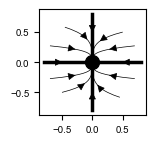

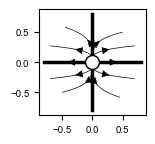

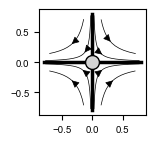

In [ ]:
def SN_jk(t, z, para):

    mu,n,j,k,a,b = para
    z = np.array(z)

    zdot = np.zeros(n)

    if j>0:
        zdot[:j] = z[:j]**2 + mu
    if k>0:
        zdot[j:j+k] = z[j:j+k]*a
    if n-(j+k)>0:
        zdot[j+k:] = -z[j+k:]*b

    return zdot

Ng=75
x_range=np.linspace(-1,1,Ng)
y_range=np.linspace(-1,1,Ng)
grid_ss = np.meshgrid(x_range, y_range)
Xg,Yg=grid_ss


# attractor

a = np.array([1,1])
b = np.array([1,.25])

def flow_model(t,z): 
        return SN_jk(t,z,[0,2,0,0,a,b]) 
U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 

plt.figure(figsize=(3.5*inCm,3.5*inCm))
ax = plt.gca()

radius = 0.8
distance = np.sqrt(Xg**2 + Yg**2)
mask = distance <= radius

# Apply the mask to U and V
U_masked = np.where(mask, U, np.nan)
V_masked = np.where(mask, V, np.nan)
ax.streamplot(Xg, Yg, U_masked, V_masked, density=0.33, color='k', arrowsize=1.1, linewidth=0.5,broken_streamlines=False)

plt.plot([-0.8,0.8],[0,0],'-k',lw=2.5)
plt.plot([0,0],[-0.8,0.8],'-k',lw=2.5)

plt.plot(0,0,'ok',ms=10,mec='k')
if saveFigs: plt.savefig('2d_sink.svg')


# repeller

a = np.array([1,.25])
b = np.array([1,.5])

def flow_model(t,z): 
        return SN_jk(t,z,[0,2,0,2,a,b]) 
U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 

plt.figure(figsize=(3.5*inCm,3.5*inCm))
ax = plt.gca()

radius = 0.8
distance = np.sqrt(Xg**2 + Yg**2)
mask = distance <= radius

# Apply the mask to U and V
U_masked = np.where(mask, U, np.nan)
V_masked = np.where(mask, V, np.nan)
ax.streamplot(Xg, Yg, U_masked, V_masked, density=0.33, color='k', arrowsize=1.1, linewidth=0.5,broken_streamlines=False)

plt.plot([-0.8,0.8],[0,0],'-k',lw=2.5)
plt.plot([0,0],[-0.8,0.8],'-k',lw=2.5)

plt.plot(0,0,'ow',ms=10,mec='k')
if saveFigs: plt.savefig('2d_repeller.svg')

# saddle

a = np.array([1])
b = np.array([1])

def flow_model(t,z): 
        return SN_jk(t,z,[0,2,0,1,a,b]) 
U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 

plt.figure(figsize=(3.5*inCm,3.5*inCm))
ax = plt.gca()

radius = 0.8
distance = np.sqrt(Xg**2 + Yg**2)
mask = distance <= radius

# Apply the mask to U and V
U_masked = np.where(mask, U, np.nan)
V_masked = np.where(mask, V, np.nan)
ax.streamplot(Xg, Yg, U_masked, V_masked, density=0.28, color='k', arrowsize=1.1, linewidth=0.5,broken_streamlines=False)

plt.plot([-0.8,0.8],[0,0],'-k',lw=2.5)
plt.plot([0,0],[-0.8,0.8],'-k',lw=2.5)

plt.plot(0,0,'o',color='lightgrey',ms=10,mec='k')
if saveFigs: plt.savefig('2d_saddle.svg')






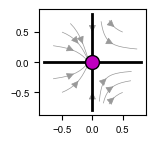

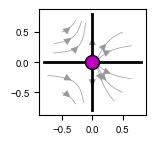

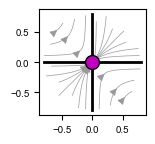

In [ ]:
# SN type 1,0
a = np.array([1])
b = np.array([.2])

def flow_model(t,z): 
        return SN_jk(t,z,[0,2,1,0,a,b]) 
U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 

plt.figure(figsize=(3.5*inCm,3.5*inCm))
ax = plt.gca()

radius = 0.8
distance = np.sqrt(Xg**2 + Yg**2)
mask = distance <= radius

# Apply the mask to U and V
U_masked = np.where(mask, U, np.nan)
V_masked = np.where(mask, V, np.nan)
ax.streamplot(Xg, Yg, U_masked, V_masked, density=0.3, color=[0.6,0.6,0.6,1], arrowsize=1.1, linewidth=0.5,broken_streamlines=False)

plt.plot([-0.8,0.8],[0,0],'-k',lw=2)
plt.plot([0,0],[-0.8,0.8],'-k',lw=2)

plt.plot(0,0,'om',ms=10,mec='k')
if saveFigs: plt.savefig('2d_SN_1_0.svg')

# SN type 1,1

a = np.array([.2])
b = np.array([1])
def flow_model(t,z): 
        return SN_jk(t,z,[0,2,1,1,a,b]) 
U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 

plt.figure(figsize=(3.5*inCm,3.5*inCm))
ax = plt.gca()

radius = 0.8
distance = np.sqrt(Xg**2 + Yg**2)
mask = distance <= radius

# Apply the mask to U and V
U_masked = np.where(mask, U, np.nan)
V_masked = np.where(mask, V, np.nan)
ax.streamplot(Xg, Yg, U_masked, V_masked, density=0.3, color=[0.6,0.6,0.6,1], arrowsize=1.1, linewidth=0.5,broken_streamlines=False)

plt.plot([-0.8,0.8],[0,0],'-k',lw=2)
plt.plot([0,0],[-0.8,0.8],'-k',lw=2)

plt.plot(0,0,'om',ms=10,mec='k')
if saveFigs: plt.savefig('2d_SN_1_1.svg')

# SN type 2,0

a = np.array([1])
b = np.array([1])
def flow_model(t,z): 
        return SN_jk(t,z,[0,2,2,0,a,b]) 
U,V=fun.vector_field(flow_model,grid_ss,dim='2D') 

plt.figure(figsize=(3.5*inCm,3.5*inCm))
ax = plt.gca()

radius = 0.85
distance = np.sqrt(Xg**2 + Yg**2)
mask = distance <= radius

# Apply the mask to U and V
U_masked = np.where(mask, U, np.nan)
V_masked = np.where(mask, V, np.nan)
ax.streamplot(Xg, Yg, U_masked, V_masked, density=0.35, color=[0.6,0.6,0.6,1], arrowsize=1.1, linewidth=0.5,broken_streamlines=False)

plt.plot([-0.8,0.8],[0,0],'-k',lw=2)
plt.plot([0,0],[-0.8,0.8],'-k',lw=2)

plt.plot(0,0,'om',ms=10,mec='k')
if saveFigs: plt.savefig('2d_SN_2_0.svg')




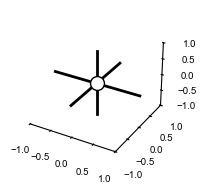

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
mu, n, j, k, a, b = 0, 3, 0, 0, np.array([1, 1, 1]), np.array([.1, 1, 0.5])

# Plot
fig = plt.figure(figsize=(5*inCm, 5*inCm))
ax = fig.add_subplot(111, projection='3d')

# Plot axes and origin
ax.plot([-1, 1], [0, 0], [0, 0], 'k-', lw=2)
ax.plot([0, 0], [-1, 1], [0, 0], 'k-', lw=2)
ax.plot([0, 0], [0, 0], [-1, 1], 'k-', lw=2)
ax.scatter(0, 0, 0, c='w', s=100,edgecolors='k')
fun.noBackground(ax)   # keep your background removal

# Labels and limits
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_zlim(-1, 1)
if saveFigs: plt.savefig('3d_template.svg')
